# Лабораторная 7

## 1. Построение описательный статистик двух финансовых активов

### Импорт библиотек:

In [273]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, coint
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model

### Загрузка исторических цен (закрытия на конец дня) и расчёт ежедневных доходностей

In [274]:
tickers = ['MSFT', 'AAPL']
start_date = '2020-01-01'
end_date = '2024-12-31'

data = yf.download(tickers, start=start_date, end=end_date)['Close']  # type: ignore
data.dropna(inplace=True)
returns = data.pct_change().dropna()

[*********************100%***********************]  2 of 2 completed


### Построение графика цен

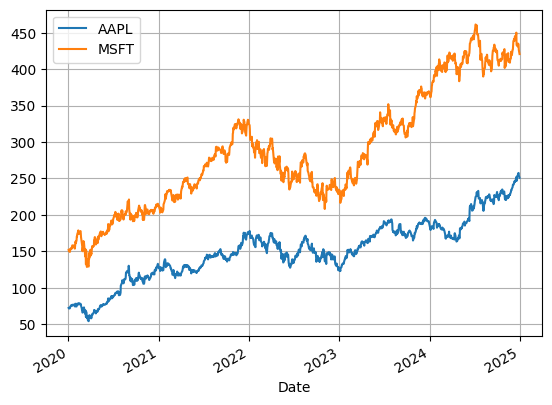

In [275]:
data.plot()
plt.grid()
plt.legend()
plt.show()

### График доходностей


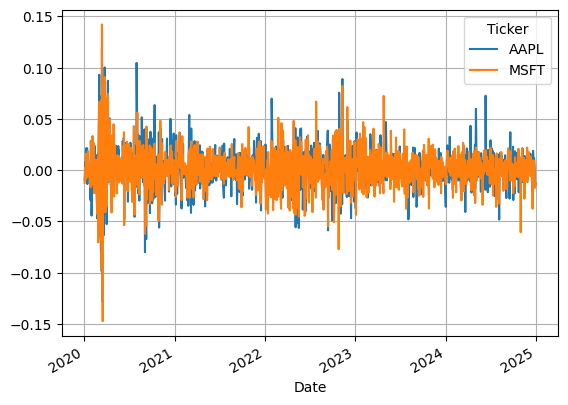

In [276]:
returns.plot()
plt.grid()
plt.show()

### Описательные статистики дневных доходностей

In [277]:
returns.describe()

Ticker,AAPL,MSFT
count,1256.000000,1256.000000
mean,0.001189,0.000995
std,0.019962,0.019217
min,-0.128647,-0.147390
25%,-0.008426,-0.008248
50%,0.001210,0.001113
75%,0.012017,0.010947
max,0.119808,0.142169


### Графики Бокса-Вискера дневных доходностей

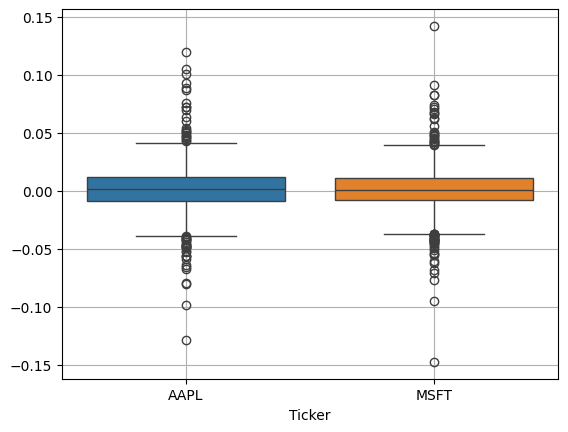

In [278]:
sns.boxplot(returns)
plt.grid()
plt.show()

### Гистограммы распределения дневных доходностей

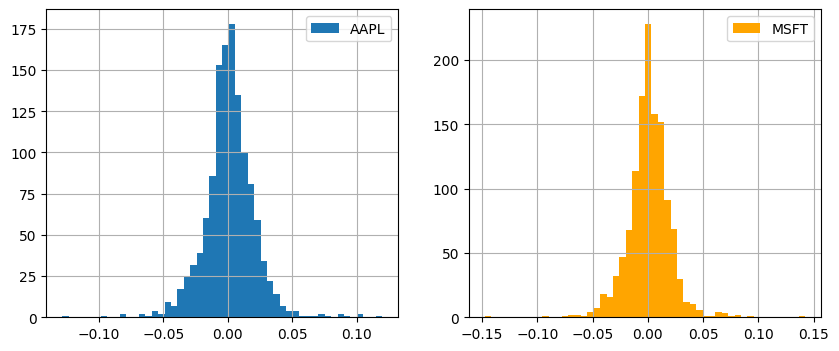

In [279]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

ax1.hist(returns['AAPL'], bins=50, label='AAPL')
ax1.grid()
ax1.legend()

ax2.hist(returns['MSFT'], bins=50, color='orange', label='MSFT')
ax2.grid()
ax2.legend()

plt.show()

### Критерии стационарности ряда: ADF-test и KPSS-test

In [280]:
def adf_test(series, title=''):
    print(f'Augmented Dickey-Fuller Test ({title}):')
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values: {result[4]}')
    print('Reject H0 (Stationary)' if result[1] <= 0.05 else 'Fail to Reject H0 (Non-Stationary)')
    print('---')

def kpss_test(series, title=''):
    print(f'KPSS Test ({title}):')
    result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'KPSS Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values: {result[3]}')
    print('Fail to Reject H0 (Stationary)' if result[1] <= 0.05 else 'Reject H0 (Non-Stationary)')
    print('---')

# Применяем тесты к доходностям
for ticker in tickers:
    adf_test(returns[ticker], title=ticker)
    kpss_test(returns[ticker], title=ticker)

Augmented Dickey-Fuller Test (MSFT):
ADF Statistic: -11.299799
p-value: 0.000000
Critical Values: {'1%': np.float64(-3.4356048614183443), '5%': np.float64(-2.8638605461891617), '10%': np.float64(-2.5680054872544145)}
Reject H0 (Stationary)
---
KPSS Test (MSFT):
KPSS Statistic: 0.095016
p-value: 0.100000
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Reject H0 (Non-Stationary)
---
Augmented Dickey-Fuller Test (AAPL):
ADF Statistic: -11.351124
p-value: 0.000000
Critical Values: {'1%': np.float64(-3.4356048614183443), '5%': np.float64(-2.8638605461891617), '10%': np.float64(-2.5680054872544145)}
Reject H0 (Stationary)
---
KPSS Test (AAPL):
KPSS Statistic: 0.108102
p-value: 0.100000
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Reject H0 (Non-Stationary)
---


/tmp/ipykernel_13633/3555273386.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')
/tmp/ipykernel_13633/3555273386.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression='c', nlags='auto')


### p-value обоих тестов близко к нулю, ряды стационарны. Значит, можно на их основе построить GARCH-модель

## 2. Построение модели GARCH(1,1) на основе случайных величин

Модель GARCH(1,1) (Generalized Autoregressive Conditional Heteroskedasticity) для временного ряда доходностей $r_t$ записывается как: $$\begin{gathered} r_t = \mu + \varepsilon_t, \\ \varepsilon_t=\sigma_t z_t, \\ \sigma^2_t=\omega + \alpha \varepsilon^2_{t-1} + \beta \sigma^2_{t-1} \end{gathered} $$  где $r_t$ - исследуемый ряд, $z_t$ - случайные величины, $\omega > 0$, $\alpha, \beta \ge 0$, $\alpha + \beta < 1$ (условие стационарности). $\mu$ задаётся в зависимости от центрированности ряда.
На реальных данных параметры чаще всего оцениваются методом максимального правдоподобия. Процесс $r_t$ должен быть процессом с условной гетероскедакстичностью, т. е. может быть представлен следующим образом $r_t = \sigma_t z_t$  

В рамках лабораторной работы для симуляции временных рядов и построения на них модели GARCH, зададим истинные значения $\omega, \alpha, \beta$ и построим ряды из приведённых формул, а затем оценим, как модель оценит эти параметры. $\omega = 0.1, \alpha = 0.1, \beta = 0.8$

In [281]:
def simulate_garch_process(omega: float, alpha: float, beta: float, T: int, distribution, *args):
    r = np.zeros(T)
    sigma2 = np.zeros(T)
    sigma2[0] = omega / (1 - alpha - beta)

    for t in range(1, T):
        sigma2[t] = omega + alpha * (r[t-1]**2) + beta * sigma2[t-1]
        r[t] = np.sqrt(sigma2[t]) * distribution(*args)

    return r, sigma2

OMEGA = 0.1
ALPHA = 0.1
BETA = 0.8
T = 1000
PREDICTION_STEPS = 20

In [282]:
def garch_mse(r, sigma2, T:int):
    slicing = int(T * 0.8)
    train = r[:slicing]
    model_train = arch_model(train, vol='GARCH', p=1, q=1)
    res_train = model_train.fit(disp='off')
    # Прогноз волатильности на 200 шагов вперёд (условной дисперсии)
    forecast = res_train.forecast(horizon=200)
    pred_vol_forecast = np.sqrt(forecast.variance.values[-1, :])  # прогнозные СКО

    # Сравните с истинной волатильностью на тесте (если знаете)
    true_vol_test = sigma2[slicing:]  # из симуляции для индексов 800:1000
    mse_forecast = np.mean((pred_vol_forecast - true_vol_test)**2)
    return mse_forecast

### 2.1. Нормальное распределение

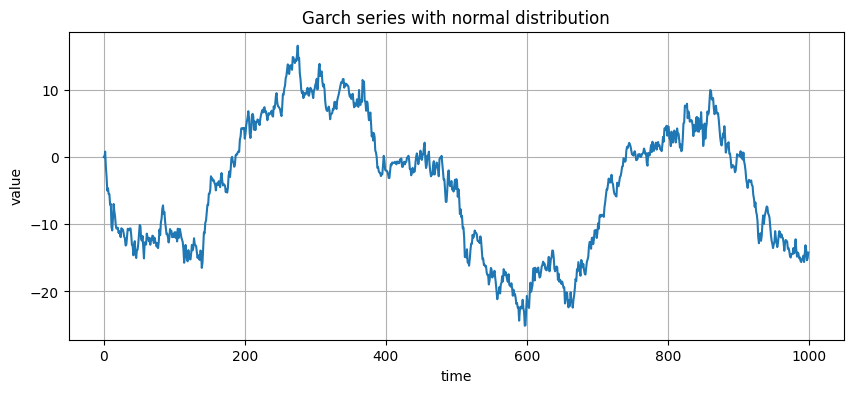

In [283]:
r_norm, sigma2_norm = simulate_garch_process(OMEGA, ALPHA, BETA, T, np.random.normal, 0, 1)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plt.plot(np.cumsum(r_norm))
plt.title("Garch series with normal distribution")
plt.xlabel("time")
plt.ylabel("value")
plt.grid()
plt.show()

In [284]:
normal_model = arch_model(r_norm[:-PREDICTION_STEPS], vol="GARCH", p=1, q=1, dist='normal')
normal_model_fitted = normal_model.fit(disp="off")
print(normal_model_fitted.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -1337.00
Distribution:                  Normal   AIC:                           2682.00
Method:            Maximum Likelihood   BIC:                           2701.55
                                        No. Observations:                  980
Date:                Wed, Apr 08 2026   Df Residuals:                      979
Time:                        13:05:15   Df Model:                            1
                                  Mean Model                                  
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
mu         -3.2850e-03  2.904e-02     -0.113      0.

In [285]:
forecasts_normal = normal_model_fitted.forecast(horizon=PREDICTION_STEPS)
print(f"\nПрогноз дисперсии на {PREDICTION_STEPS} шагов:")
volatility_forecast_normal = forecasts_normal.variance.iloc[-1]
print(volatility_forecast_normal)


Прогноз дисперсии на 20 шагов:
h.01    0.624475
h.02    0.650724
h.03    0.674808
h.04    0.696907
h.05    0.717184
h.06    0.735789
h.07    0.752861
h.08    0.768524
h.09    0.782897
h.10    0.796085
h.11    0.808185
h.12    0.819288
h.13    0.829475
h.14    0.838822
h.15    0.847399
h.16    0.855269
h.17    0.862490
h.18    0.869115
h.19    0.875195
h.20    0.880773
Name: 979, dtype: float64


In [286]:
resid_norm = normal_model_fitted.resid  # r_t
cond_vol_norm = normal_model_fitted.conditional_volatility  # sigma_t
std_resid_norm = resid_norm / cond_vol_norm # z_t

#### Построим график оценённой волатильности / реальной

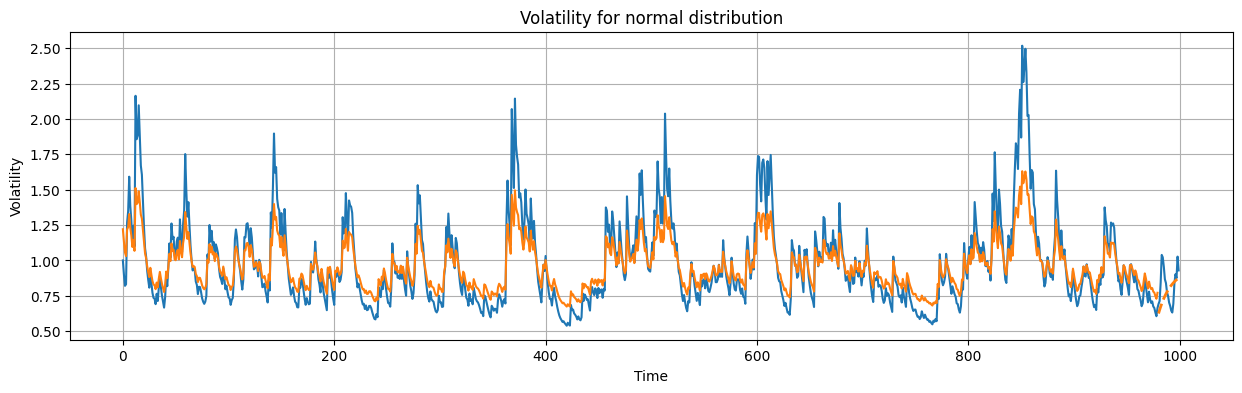

In [297]:
fig, ax = plt.subplots(1, 1, figsize=(15, 4))
plt.plot(sigma2_norm)
plt.plot(cond_vol_norm, color='tab:orange')

x_predicted = np.linspace(T - PREDICTION_STEPS, T, PREDICTION_STEPS)
plt.plot(x_predicted, volatility_forecast_normal, color='tab:orange', linestyle='--', linewidth=2)

plt.title("Volatility for normal distribution")
plt.xlabel("Time")
plt.ylabel("Volatility")
plt.grid()

#### Посчитаем среднюю квадратичную ошибку оценённой волатильности

In [296]:
norm_mse = ((normal_model_fitted.conditional_volatility - sigma2_norm[:-PREDICTION_STEPS]) ** 2).mean()
print(f"MSE : {norm_mse:.4f}")

MSE : 0.0214


#### Оценим параметры нормального распределения (математическое ожидание и дисперсию)

In [298]:
print(f"Estimated mean: {np.mean(std_resid_norm)}")
print(f"Estimated variance: {np.var(std_resid_norm)}")

Estimated mean: -0.011254672000103019
Estimated variance: 1.0015597599437183


### 2.2. Variance Gamma

In [ ]:
from scipy import special

def vg_rvs(mu, theta, sigma, nu):
    """
    Генерация случайных чисел из VG распределения
    """
    # 1. Генерируем случайное время из гамма-распределения
    # Параметры: shape = 1/nu, scale = nu [citation:3]
    g = np.random.gamma(shape=1/nu, scale=nu)
    
    # 2. Условное нормальное распределение:
    # VG = theta * g + sigma * sqrt(g) * N(0,1)
    # где g - сгенерированное гамма-время
    normal = np.random.normal(0, 1)
    vg = theta * g + sigma * np.sqrt(g) * normal + mu
    
    return vg

def vg_pdf_one_point(x=0.0, c=0.0, sigma=1.0, theta=0.0, nu=1.0):
	''' VarGamma probability density function in a point x '''
	temp1 = 2.0 / ( sigma*(2.0*np.pi)**0.5*nu**(1/nu)*special.gamma(1/nu) )
	temp2 = ((2*sigma**2/nu+theta**2)**0.5)**(0.5-1/nu)
	temp3 = np.exp(theta*(x-c)/sigma**2) * abs(x-c)**(1/nu - 0.5)
	temp4 = special.kv(1/nu - 0.5, abs(x-c)*(2*sigma**2/nu+theta**2)**0.5/sigma**2)
	return temp1*temp2*temp3*temp4

def vg_pdf(x=0.0, c=0.0, sigma=1.0, theta=0.0, nu=1.0):
	''' VarGamma probability density function of an array or a point x '''
	if isinstance(x, (int, float)): # works with lists and arrays
		return vg_pdf_one_point(x, c, sigma, theta, nu)
	else:
		return [vg_pdf_one_point(xi, c, sigma, theta, nu) for xi in x]

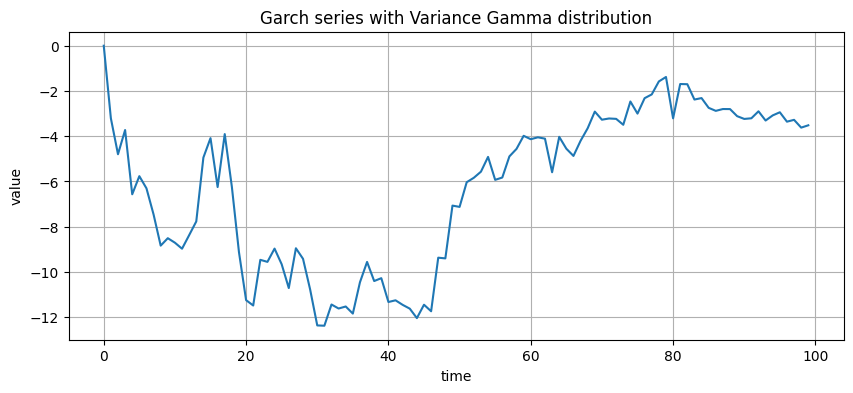

In [ ]:
r_vg, sigma2_vg = simulate_garch_process(OMEGA, ALPHA, BETA, T, vg_rvs, 0, 0, 1, 1)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plt.plot(np.cumsum(r_vg))
plt.title("Garch series with Variance Gamma distribution")
plt.xlabel("time")
plt.ylabel("value")
plt.grid()
plt.show()

In [ ]:
vg_model = arch_model(r_vg, vol="GARCH", p=1, q=1)
vg_model_fitted = vg_model.fit(disp="off")
vg_model_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -133.221
Distribution:                  Normal   AIC:                           274.443
Method:            Maximum Likelihood   BIC:                           284.864
                                        No. Observations:                  100
Date:                Wed, Apr 08 2026   Df Residuals:                       99
Time:                        12:47:30   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu             0.0214  7.438e-02      0.288      0.774 [ -0.124,  0.167]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      1.1508e-08  9.526e-03  1.208e-06      1.000 [-1.867e-02,1.867e-02]
alpha[1]   9.9831e-16  3.203e-02  3.117e-14      1.000 [-6.277e-02,6.277e-02]
beta[1]        0.9772  3.604e-02     27.117 6.162e-162      [  0.907,  1.048]
=============================================================================

Covariance estimator: robust
"""

#### Вычислим среднеквадратичную ошибку оценки волатильности

In [ ]:
norm_mse = ((normal_model_fitted.conditional_volatility - sigma2_norm) ** 2).mean()
print(f"MSE : {norm_mse:.4f}")

MSE : 0.0286


#### $\alpha$-устойчивое распределение

В качестве $\alpha$ выберем 1.9

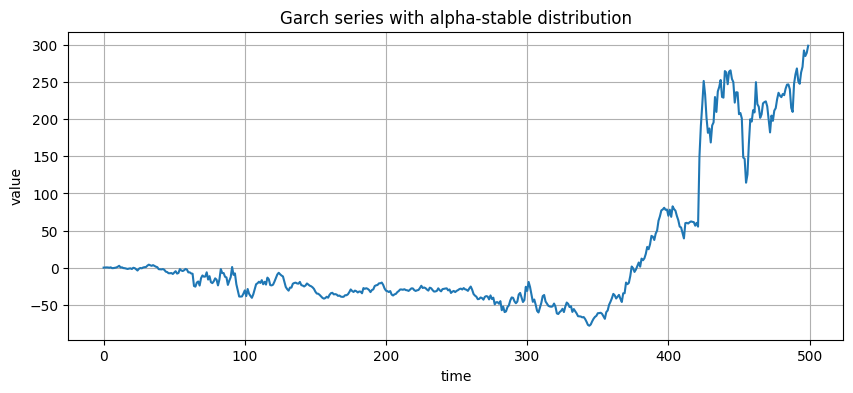

In [ ]:
r_alpha_stable, sigma2_alpha_stable = simulate_garch_process(OMEGA, ALPHA, BETA, 500, stats.levy_stable.rvs, 1.9, 0, 0, 1)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
plt.plot(np.cumsum(r_alpha_stable))
plt.title("Garch series with alpha-stable distribution")
plt.xlabel("time")
plt.ylabel("value")
plt.grid()
plt.show()

In [ ]:
as_model = arch_model(r_alpha_stable, vol="GARCH", p=1, q=1, dist='t')
as_model_fitted = as_model.fit(disp="off")
as_model_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Constant Mean - GARCH Model Results                         
====================================================================================
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -1485.09
Distribution:      Standardized Student's t   AIC:                           2980.18
Method:                  Maximum Likelihood   BIC:                           3001.25
                                              No. Observations:                  500
Date:                      Wed, Apr 08 2026   Df Residuals:                      499
Time:                              12:47:31   Df Model:                            1
                               Mean Model                               
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -0.0646      0.116     -0.559      0.576 [ -0.291,  0.162]
                             Volatility Model                             
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.1575  7.948e-02      1.981  4.757e-02 [1.686e-03,  0.313]
alpha[1]       0.1128  1.656e-02      6.811  9.696e-12 [8.035e-02,  0.145]
beta[1]        0.8872  2.066e-02     42.935      0.000   [  0.847,  0.928]
                              Distribution                              
========================================================================
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
nu             5.3303      1.295      4.117  3.832e-05 [  2.793,  7.868]
========================================================================

Covariance estimator: robust
"""

## 5. GARCH(1,1) на реальных данных

In [ ]:


returns_scaled = returns * 100
model = arch_model(returns_scaled['AAPL'])

In [ ]:
model_fitted = model.fit(disp='off')

In [ ]:
model_fitted.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                     Constant Mean - GARCH Model Results                      
==============================================================================
Dep. Variable:                   AAPL   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2507.20
Distribution:                  Normal   AIC:                           5022.39
Method:            Maximum Likelihood   BIC:                           5042.93
                                        No. Observations:                 1256
Date:                Wed, Apr 08 2026   Df Residuals:                     1255
Time:                        12:47:31   Df Model:                            1
                                Mean Model                                
==========================================================================
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.1592  5.124e-02      3.107  1.890e-03 [5.877e-02,  0.260]
                              Volatility Model                             
===========================================================================
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
omega          0.1028  7.331e-02      1.402      0.161 [-4.090e-02,  0.246]
alpha[1]       0.0840  3.249e-02      2.586  9.721e-03  [2.033e-02,  0.148]
beta[1]        0.8883  4.769e-02     18.626  1.978e-77    [  0.795,  0.982]
===========================================================================

Covariance estimator: robust
"""

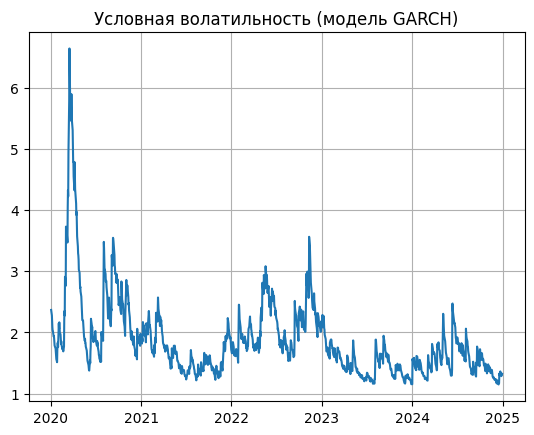

In [ ]:
conditional_volatility = model_fitted.conditional_volatility
plt.plot(conditional_volatility)
plt.title('Условная волатильность (модель GARCH)')
plt.grid()
plt.show()

In [ ]:
forecasts = model_fitted.forecast(horizon=5)
print("\nПрогноз дисперсии на 5 шагов:")
print(forecasts.variance.iloc[-1])


Прогноз дисперсии на 5 шагов:
h.1    1.848072
h.2    1.899614
h.3    1.949726
h.4    1.998449
h.5    2.045820
Name: 2024-12-30 00:00:00, dtype: float64


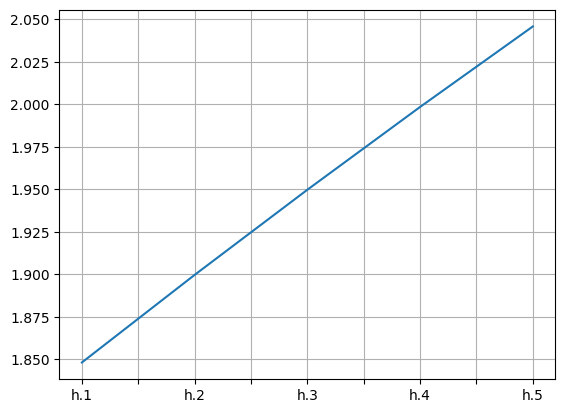

In [ ]:
forecasts.variance.iloc[-1].plot()
plt.grid()
plt.show()

In [ ]:
test_data = yf.download('AAPL', start='2025-01-01', end='2025-12-31')['Close']  # type: ignore
returns_test = test_data.pct_change().dropna()
test_data.head()

[*********************100%***********************]  1 of 1 completed


Ticker,AAPL
Date,
2025-01-02,242.525162
2025-01-03,242.037811
2025-01-06,243.668900
2025-01-07,240.894073
2025-01-08,241.381409


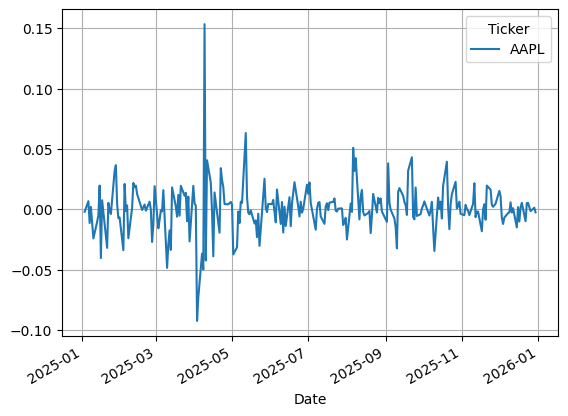

In [ ]:
returns_test.plot()
#forecasts.variance.iloc[-1].plot()
plt.grid()
plt.show()